In [1]:
# Load df_artists, df_songs, and df_artists_network_metrics from project CSVs
import pandas as pd

base = '/Users/jamesemcnally/Documents/GitHub/spring-2026-hitmakers/'

df_artists                = pd.read_csv(base + 'df_artists.csv')
df_songs                  = pd.read_csv(base + 'df_songs.csv')
df_artists_network_metrics = pd.read_csv(base + 'df_artists_network_metrics.csv')

print(f'df_artists:                 {df_artists.shape}')
print(f'df_songs:                   {df_songs.shape}')
print(f'df_artists_network_metrics: {df_artists_network_metrics.shape}')


df_artists:                 (13609, 54)
df_songs:                   (38383, 43)
df_artists_network_metrics: (14224, 26)


In [2]:
# ── 1-hit wonder vs. hitmaker analysis, by metric and period ──────────────────
# Metrics: any charted song, top 20, top 10, #1
# Periods: (a) whole timeline, (b) by decade, (c) 4-year windows 2001–2020

valid_names = set(df_artists['name'])
songs = df_songs[df_songs['name'].isin(valid_names)].copy()

yr_min = int(songs['first_charting_year'].min())
yr_max = int(songs['first_charting_year'].max())

decade_start = (yr_min // 10) * 10
decades  = [(f"{d}s",      d,   d+9) for d in range(decade_start, 2030, 10) if d <= yr_max]
four_yrs = [(f"{y}–{y+3}", y,   y+3) for y in range(2001, 2021, 4)]

METRICS = [
    ('Any charting song', None),
    ('Top 20 song',       20),
    ('Top 10 song',       10),
    ('#1 hit song',        1),
]

def period_stats(df, start, end, max_pos):
    s = df[df['first_charting_year'].between(start, end)]
    if max_pos is not None:
        s = s[s['peak_pos'] <= max_pos]
    counts = s.groupby('name').size()
    if len(counts) == 0:
        return None
    total = len(counts)
    one   = (counts == 1).sum()
    multi = (counts >  1).sum()
    return dict(total=total, one=one, multi=multi,
                pct_one=100*one/total, pct_multi=100*multi/total,
                top10=counts.nlargest(10))

def print_block(lbl, r):
    if r is None:
        return
    print(f"  {lbl:<15}  n={r['total']:5,}  |"
          f"  1 only: {r['one']:4,} ({r['pct_one']:4.1f}%)"
          f"  |  2+: {r['multi']:4,} ({r['pct_multi']:4.1f}%)")
    top = ",  ".join(f"{i}. {n} ({c})" for i,(n,c) in enumerate(r['top10'].items(),1))
    print(f"    ↳ Top 10: {top}")

for metric_label, max_pos in METRICS:
    print(f"\n{'═'*90}")
    print(f"  {metric_label.upper()}")
    print(f"{'═'*90}")

    print(f"\n  (a) Whole timeline ({yr_min}–{yr_max})")
    print_block(f"{yr_min}–{yr_max}", period_stats(songs, yr_min, yr_max, max_pos))

    print(f"\n  (b) By decade")
    for lbl, s, e in decades:
        print_block(lbl, period_stats(songs, s, e, max_pos))

    print(f"\n  (c) 4-year periods, 2001–2020")
    for lbl, s, e in four_yrs:
        print_block(lbl, period_stats(songs, s, e, max_pos))



══════════════════════════════════════════════════════════════════════════════════════════
  ANY CHARTING SONG
══════════════════════════════════════════════════════════════════════════════════════════

  (a) Whole timeline (1958–2026)
  1958–2026        n=8,533  |  1 only: 4,374 (51.3%)  |  2+: 4,159 (48.7%)
    ↳ Top 10: 1. drake (361),  2. taylor swift (277),  3. future (221),  4. glee cast (206),  5. lil wayne (180),  6. lil baby (156),  7. nicki minaj (147),  8. kanye west (131),  9. travis scott (125),  10. justin bieber (120)

  (b) By decade
  1950s            n=  459  |  1 only:  271 (59.0%)  |  2+:  188 (41.0%)
    ↳ Top 10: 1. fats domino (12),  2. pat boone (12),  3. chuck berry (11),  4. tommy edwards (11),  5. connie francis (10),  6. frankie avalon (10),  7. nat king cole (10),  8. the rebels (10),  9. duane eddy his twangy guitar (9),  10. jack scott (9)
  1960s            n=1,920  |  1 only:  949 (49.4%)  |  2+:  971 (50.6%)
    ↳ Top 10: 1. elvis presley (72),  2. th

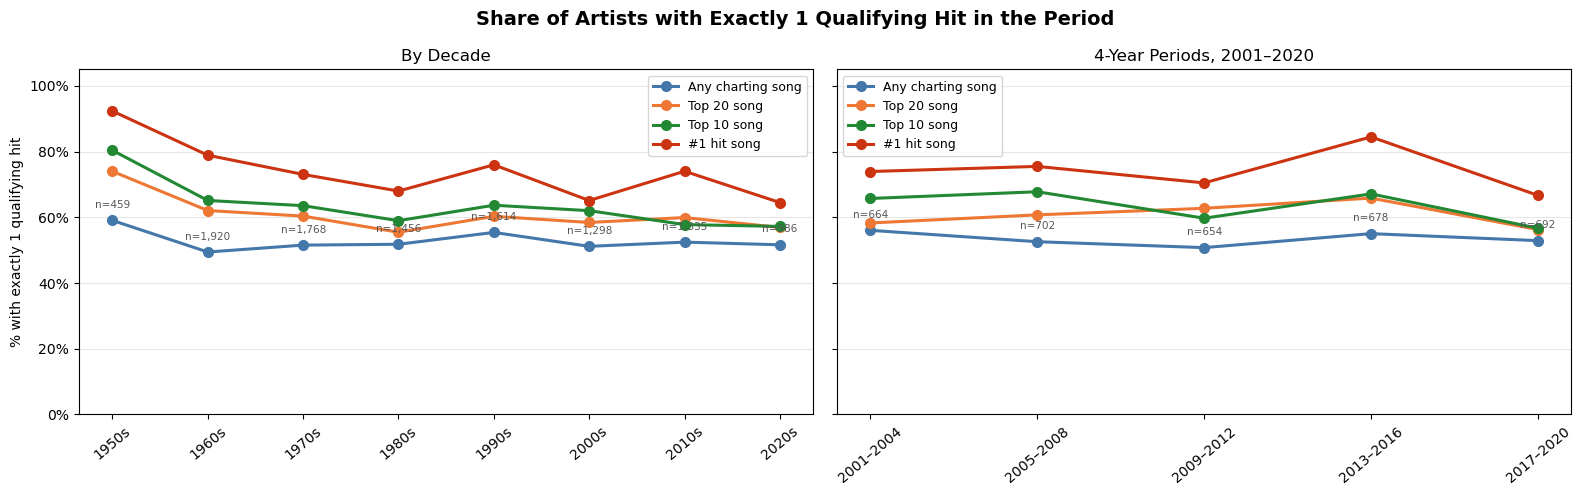

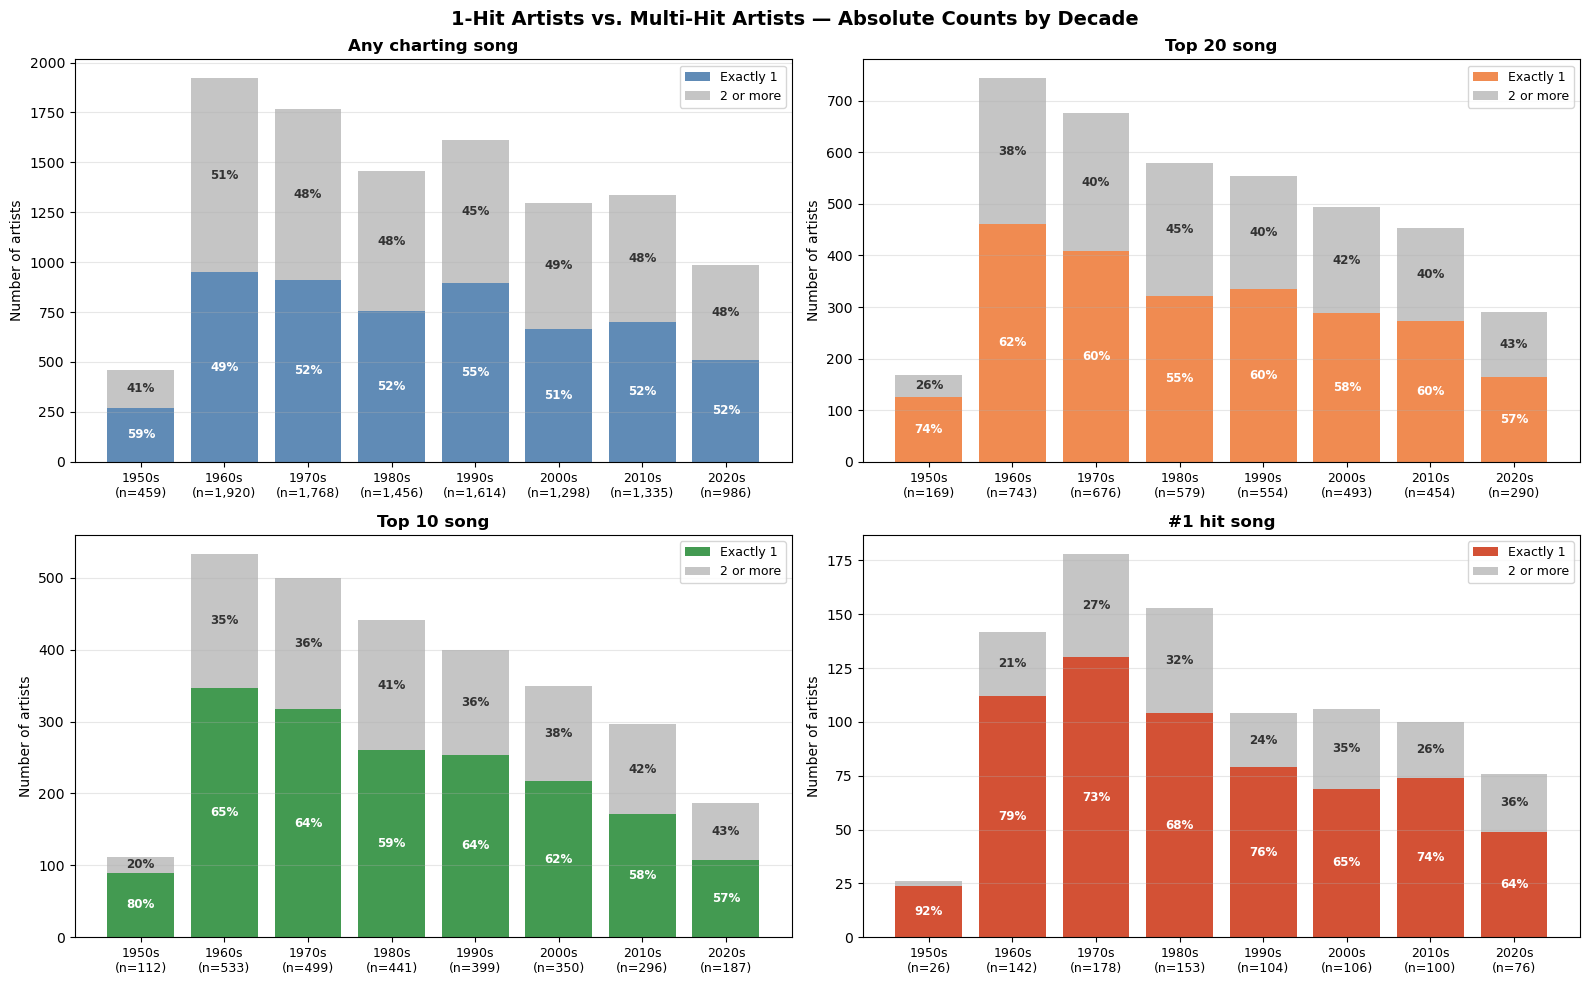

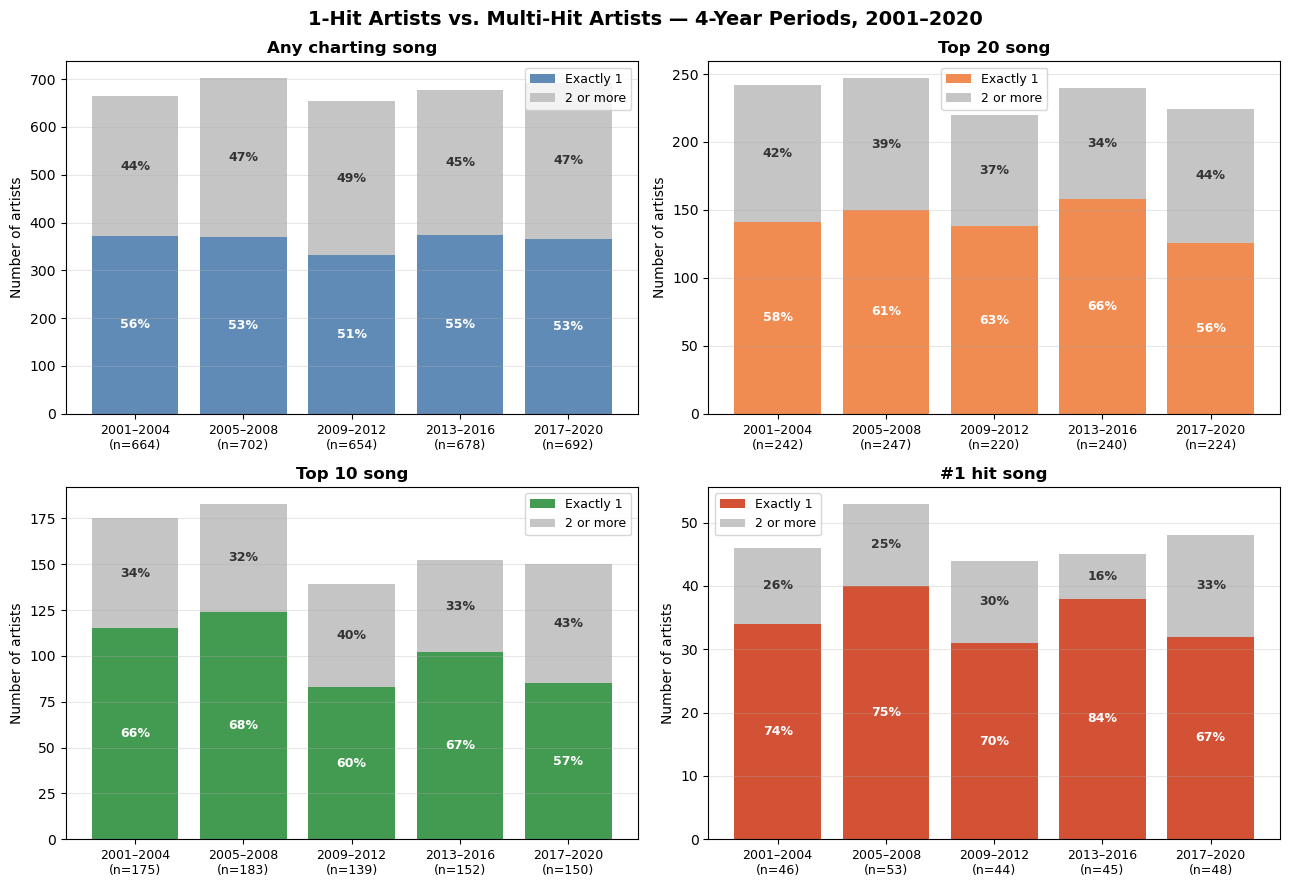

In [3]:
# ── Visuals: 1-hit wonder vs. hitmaker analysis ────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

METRICS = [
    ('Any charting song', None,  '#4477AA'),
    ('Top 20 song',       20,    '#EE7733'),
    ('Top 10 song',       10,    '#228833'),
    ('#1 hit song',        1,    '#CC3311'),
]

yr_min = int(songs['first_charting_year'].min())
yr_max = int(songs['first_charting_year'].max())
decade_start = (yr_min // 10) * 10
decades  = [(f"{d}s",      d,   d+9) for d in range(decade_start, 2030, 10) if d <= yr_max]
four_yrs = [(f"{y}–{y+3}", y,   y+3) for y in range(2001, 2021, 4)]

# ── Figure 1: % 1-hit wonders over time (line chart, both period types) ─────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
fig.suptitle('Share of Artists with Exactly 1 Qualifying Hit in the Period',
             fontsize=14, fontweight='bold')

for ax, periods, title in [
    (ax1, decades,   'By Decade'),
    (ax2, four_yrs,  '4-Year Periods, 2001–2020'),
]:
    labels = [lbl for lbl, *_ in periods]
    for metric_label, max_pos, color in METRICS:
        pcts, ns = [], []
        for lbl, s, e in periods:
            r = period_stats(songs, s, e, max_pos)
            pcts.append(r['pct_one'] if r else np.nan)
            ns.append(r['total']    if r else 0)
        ax.plot(labels, pcts, marker='o', color=color, linewidth=2.2,
                markersize=7, label=metric_label)
        # annotate n on the top metric (any charting song) only
        if max_pos is None:
            for i, (p, n) in enumerate(zip(pcts, ns)):
                if not np.isnan(p):
                    ax.annotate(f"n={n:,}", xy=(i, p), xytext=(0, 9),
                                textcoords='offset points', ha='center',
                                fontsize=7.5, color='#555')

    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_ylim(0, 105)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('% with exactly 1 qualifying hit' if ax == ax1 else '')
    ax.tick_params(axis='x', rotation=40)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# ── Figure 2: Stacked bars — absolute counts by decade, 2×2 grid ─────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('1-Hit Artists vs. Multi-Hit Artists — Absolute Counts by Decade',
             fontsize=14, fontweight='bold')

for ax, (metric_label, max_pos, color) in zip(axes.flat, METRICS):
    ones, multis, xlabels = [], [], []
    for lbl, s, e in decades:
        r = period_stats(songs, s, e, max_pos)
        if r:
            ones.append(r['one'])
            multis.append(r['multi'])
            xlabels.append(f"{lbl}\n(n={r['total']:,})")

    x = np.arange(len(xlabels))
    b1 = ax.bar(x, ones,   label='Exactly 1', color=color,   alpha=0.85)
    b2 = ax.bar(x, multis, label='2 or more', color='#BBBBBB', alpha=0.85,
                bottom=ones)

    for i, (o, m) in enumerate(zip(ones, multis)):
        total = o + m
        if total > 0:
            if o > 5:
                ax.text(i, o / 2,     f"{100*o/total:.0f}%", ha='center', va='center',
                        fontsize=8.5, color='white', fontweight='bold')
            if m > 5:
                ax.text(i, o + m / 2, f"{100*m/total:.0f}%", ha='center', va='center',
                        fontsize=8.5, color='#333',  fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(xlabels, fontsize=9)
    ax.set_title(metric_label, fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of artists')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ── Figure 3: Stacked bars — absolute counts, 4-year periods 2001–2020 ──────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('1-Hit Artists vs. Multi-Hit Artists — 4-Year Periods, 2001–2020',
             fontsize=14, fontweight='bold')

for ax, (metric_label, max_pos, color) in zip(axes.flat, METRICS):
    ones, multis, xlabels = [], [], []
    for lbl, s, e in four_yrs:
        r = period_stats(songs, s, e, max_pos)
        if r:
            ones.append(r['one'])
            multis.append(r['multi'])
            xlabels.append(f"{lbl}\n(n={r['total']:,})")

    x = np.arange(len(xlabels))
    ax.bar(x, ones,   label='Exactly 1', color=color,    alpha=0.85)
    ax.bar(x, multis, label='2 or more', color='#BBBBBB', alpha=0.85, bottom=ones)

    for i, (o, m) in enumerate(zip(ones, multis)):
        total = o + m
        if total > 0:
            ax.text(i, o / 2,     f"{100*o/total:.0f}%", ha='center', va='center',
                    fontsize=9, color='white', fontweight='bold')
            ax.text(i, o + m / 2, f"{100*m/total:.0f}%", ha='center', va='center',
                    fontsize=9, color='#333',  fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(xlabels, fontsize=9)
    ax.set_title(metric_label, fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of artists')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


In [5]:
# Show all columns for head and sample
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 50)

df_songs.head()

,title,name,performer_pre_normalized,original_performer_name,original_performer_name_normalized,peak_pos,wks_on_chart,first_charting_year,musicbrainz_artist_id,musicbrainz_recording_mbid,label,major_label,major_label_names,other_label,other_label_names,warner,universal,sony,label_mbid,song_genre_tags_musicbrainz,song_tags_musicbrainz,album_genre_tags_musicbrainz,song_major_genre_category_musicbrainz,album_major_genre_category_musicbrainz,aggregate_major_genre_category_musicbrainz,#_of_genres_song,#_of_genres_aggregate,spotify_id,duration_ms,release_date,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,mode,key,popularity,explicit
0,It's All In The Game,tommy edwards,Tommy Edwards,NaN,NaN,1,22,1958,0b1a0ca5-52cb-4d1d-8344-746f905ae115,7cf06b8f-a898-4f2c-a589-a98af8af6001,['Not Now Music'],False,NaN,True,['Not Now Music'],False,False,False,['b454b444-eb75-46ed-b400-19e85d8e1c64'],NaN,NaN,NaN,NaN,NaN,NaN,0,0,2lmPUdIdzlFH64PWJrw6Zb,159040.0,1/1/94,0.038,0.384,0.276,0.000000,0.309,-13.527,0.0295,105.181,0.654,1.0,3.0,49.0,0.0
1,It's Only Make Believe,conway twitty,Conway Twitty,NaN,NaN,1,21,1958,a3c60d26-90d6-4788-ba9b-a89693fc396d,4123e40f-d667-4634-919d-6e1d77a19934,['Remasters Workshop'],False,NaN,True,['Remasters Workshop'],False,False,False,['e55f5360-a4d0-43a1-b84d-f69b8510f3c6'],NaN,NaN,NaN,NaN,NaN,NaN,0,0,1xVOttVNT27FBTD8iHjOfU,132027.0,1/1/59,0.860,0.461,0.466,0.000028,0.135,-9.627,0.0598,128.537,0.251,1.0,11.0,51.0,0.0
2,Little Star,the elegants,The Elegants,NaN,NaN,1,17,1958,91919ad2-80cb-4077-bbb3-2803fa129fab,e15d4722-47a7-4874-99f6-285529503569,['Club Records'],False,NaN,True,['Club Records'],False,False,False,['9019dc41-f533-4c25-81b1-35fc98531903'],NaN,NaN,NaN,NaN,NaN,NaN,0,0,3c7KT5CN8uYRaK3xThhdYt,162773.0,7/26/05,0.873,0.408,0.397,0.000000,0.280,-12.536,0.0300,72.615,0.697,1.0,9.0,40.0,0.0
3,Nel Blu Dipinto Di Blu (Volaré),domenico modugno,Domenico Modugno,NaN,NaN,1,16,1958,b8e60837-e646-4f18-8f92-27d1173511b0,858ea2b4-7cc8-4a13-aa93-a3a5a73e71fd,['Warner Music Italy'],True,['Warner Music Italy'],False,NaN,True,False,False,['30d5acae-ae46-4689-9a91-99293a55e95e'],NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Poor Little Fool,ricky nelson,Ricky Nelson,NaN,NaN,1,11,1958,28d0c272-4d51-4c24-b31f-e20aac2ba7de,100b7f30-1519-427a-adc2-2b0d6a737db1,['Chartbuster Karaoke'],False,NaN,True,['Chartbuster Karaoke'],False,False,False,['4c44731f-f69b-4bac-b396-064980e894eb'],NaN,NaN,NaN,NaN,NaN,NaN,0,0,1ugZWl7RmEq95dea9hqorZ,153667.0,1/1/90,0.702,0.522,0.227,0.000095,0.238,-16.426,0.0318,155.514,0.839,1.0,0.0,35.0,0.0


In [6]:
# Build one-row-per-artist analysis dataframe for top 10 hitmaker classification
# Target: 0 = 1-hit wonder (exactly 1 top 10 song), 1 = hitmaker (2+ top 10 songs)
import numpy as np
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# --- Target from df_artists ---
target = (df_artists[['name', 'top_10_song_count']]
          .query('top_10_song_count >= 1')
          .copy())
target['hitmaker'] = (target['top_10_song_count'] >= 2).astype(int)

# --- First top 10 song features from df_songs ---
audio_cols = ['acousticness', 'danceability', 'energy', 'instrumentalness',
              'liveness', 'loudness', 'speechiness', 'tempo', 'valence', 'mode']

first_top10 = (df_songs[df_songs['peak_pos'] <= 10]
               .sort_values('first_charting_year')
               .groupby('name', as_index=False)
               .first()
               [['name', 'first_charting_year', 'major_label',
                 'song_major_genre_category_musicbrainz', '#_of_genres_aggregate']
                + audio_cols])

first_top10 = first_top10.rename(columns={
    'first_charting_year':                   'first_top10_year',
    'song_major_genre_category_musicbrainz': 'genre_str',
    '#_of_genres_aggregate':                 'n_genres',
})
first_top10['big3_label'] = first_top10['major_label'].fillna(False).astype(bool).astype(int)

# --- Network metrics: top10_rolling5, fillna(0) ---
nm_rename = {
    'degree_centrality_top10_rolling5':           'degree_r5',
    'betweenness_centrality_top10_rolling5':       'betweenness_r5',
    'eigenvector_centrality_top10_rolling5':       'eigenvector_r5',
    'closeness_centrality_top10_rolling5':         'closeness_r5',
    'harmonic_closeness_centrality_top10_rolling5':'harmonic_r5',
    'power_of_connected_artists_top10_rolling5':   'power_r5',
}
nm_sub = (df_artists_network_metrics
          [['name'] + list(nm_rename.keys())]
          .rename(columns=nm_rename))
nm_cols = list(nm_rename.values())

# --- Merge ---
df_ml = (target
         .merge(first_top10, on='name', how='left')
         .merge(nm_sub,      on='name', how='left'))

for col in nm_cols:
    df_ml[col] = df_ml[col].fillna(0)

# --- One-hot encode genre (multi-label: "Pop, Rock" → split) ---
genres_flat = (df_ml['genre_str']
               .dropna()
               .str.split(', ')
               .explode()
               .str.strip()
               .unique())
all_genres = sorted(genres_flat)

genre_cols = []
for g in all_genres:
    col = 'genre_' + g.lower().replace('/', '_').replace(' ', '_').replace(',', '')
    df_ml[col] = df_ml['genre_str'].str.contains(g, na=False, regex=False).astype(int)
    # mark as NaN where genre_str is missing (unknown, not "no")
    df_ml.loc[df_ml['genre_str'].isna(), col] = np.nan
    genre_cols.append(col)

# --- Summary ---
print(f'Analysis dataframe: {df_ml.shape}')
print(f'1-hit wonders: {(df_ml["hitmaker"]==0).sum()} | Hitmakers: {(df_ml["hitmaker"]==1).sum()}')
print(f'\nNull rates:')
check_cols = audio_cols + nm_cols + ['big3_label', 'n_genres'] + genre_cols
null_rates = df_ml[check_cols].isnull().mean().round(3)
print(null_rates[null_rates > 0].to_string())
print(f'\n(0 null: big3_label, n_genres, all network metrics after fillna)')


Analysis dataframe: (2346, 42)
1-hit wonders: 1396 | Hitmakers: 950

Null rates:
acousticness                        0.386
danceability                        0.386
energy                              0.386
instrumentalness                    0.386
liveness                            0.386
loudness                            0.386
speechiness                         0.386
tempo                               0.386
valence                             0.386
mode                                0.386
genre_blues                         0.806
genre_classical                     0.806
genre_country_americana             0.806
genre_easy_listening_vocal          0.806
genre_electronic_dance              0.806
genre_experimental_avant-garde      0.806
genre_folk                          0.806
genre_gospel_christian_religious    0.806
genre_hip_hop_rap                   0.806
genre_jazz                          0.806
genre_latin                         0.806
genre_metal                         0

In [7]:
# Statistical relationships: Mann-Whitney U (continuous), Fisher/chi-square (categorical)
# Effect size: rank-biserial r for continuous, odds ratio for categorical

def rank_biserial(a, b):
    u, _ = stats.mannwhitneyu(a, b, alternative='two-sided')
    return 1 - (2 * u) / (len(a) * len(b))

wonders = df_ml[df_ml['hitmaker'] == 0]
makers  = df_ml[df_ml['hitmaker'] == 1]

rows = []

# Continuous features
for col in audio_cols + nm_cols + ['n_genres']:
    a = wonders[col].dropna().values
    b = makers[col].dropna().values
    if len(a) < 10 or len(b) < 10:
        continue
    _, p = stats.mannwhitneyu(a, b, alternative='two-sided')
    r    = rank_biserial(a, b)
    rows.append(dict(feature=col, test='mann-whitney',
                     val_1hw=f'{np.median(a):.3f}', val_hm=f'{np.median(b):.3f}',
                     n_1hw=len(a), n_hm=len(b), p=p, effect=r, effect_label='r'))

# Binary/categorical features
for col in ['big3_label'] + genre_cols:
    sub = df_ml[df_ml[col].notna()].copy()
    ct  = pd.crosstab(sub[col], sub['hitmaker'])
    if ct.shape[0] < 2 or ct.shape[1] < 2:
        continue
    n_1hw = ct[0].sum() if 0 in ct.columns else 0
    n_hm  = ct[1].sum() if 1 in ct.columns else 0
    pct_1hw = 100 * ct.loc[1, 0] / n_1hw if (1 in ct.index and n_1hw > 0) else np.nan
    pct_hm  = 100 * ct.loc[1, 1] / n_hm  if (1 in ct.index and n_hm  > 0) else np.nan
    if ct.values.min() < 5:
        oddsratio, p = stats.fisher_exact(ct.values)
        test, eff_label = 'fisher', 'OR'
    else:
        chi2, p, _, _ = stats.chi2_contingency(ct.values)
        oddsratio = (ct.loc[1,1]*ct.loc[0,0]) / (ct.loc[1,0]*ct.loc[0,1]) if ct.loc[1,0]*ct.loc[0,1] > 0 else np.nan
        test, eff_label = 'chi2', 'OR'
    rows.append(dict(feature=col, test=test,
                     val_1hw=f'{pct_1hw:.1f}%', val_hm=f'{pct_hm:.1f}%',
                     n_1hw=int(n_1hw), n_hm=int(n_hm), p=p,
                     effect=oddsratio, effect_label=eff_label))

res = (pd.DataFrame(rows)
       .sort_values('p')
       .assign(sig=lambda d: d['p'].apply(
           lambda p: '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else '')))))

res['p'] = res['p'].map('{:.4f}'.format)
res['effect'] = res['effect'].map('{:.3f}'.format)
print(res[['feature','test','val_1hw','val_hm','n_1hw','n_hm','p','effect','effect_label','sig']]
      .to_string(index=False))


                         feature         test val_1hw  val_hm  n_1hw  n_hm      p effect effect_label sig
                  betweenness_r5 mann-whitney   0.000   0.000   1396   950 0.0000  0.111            r ***
                       degree_r5 mann-whitney   0.000   0.000   1396   950 0.0000  0.125            r ***
                  eigenvector_r5 mann-whitney   0.000   0.000   1396   950 0.0000  0.105            r ***
                        power_r5 mann-whitney   0.000   0.000   1396   950 0.0000  0.096            r ***
                    closeness_r5 mann-whitney   0.000   0.000   1396   950 0.0000  0.103            r ***
                     harmonic_r5 mann-whitney   0.000   0.000   1396   950 0.0000  0.096            r ***
                        n_genres mann-whitney   0.000   0.000   1395   950 0.0085  0.057            r  **
          genre_electronic_dance         chi2   16.8%   26.4%    119   337 0.0470  1.776           OR   *
               genre_hip_hop_rap         chi2 

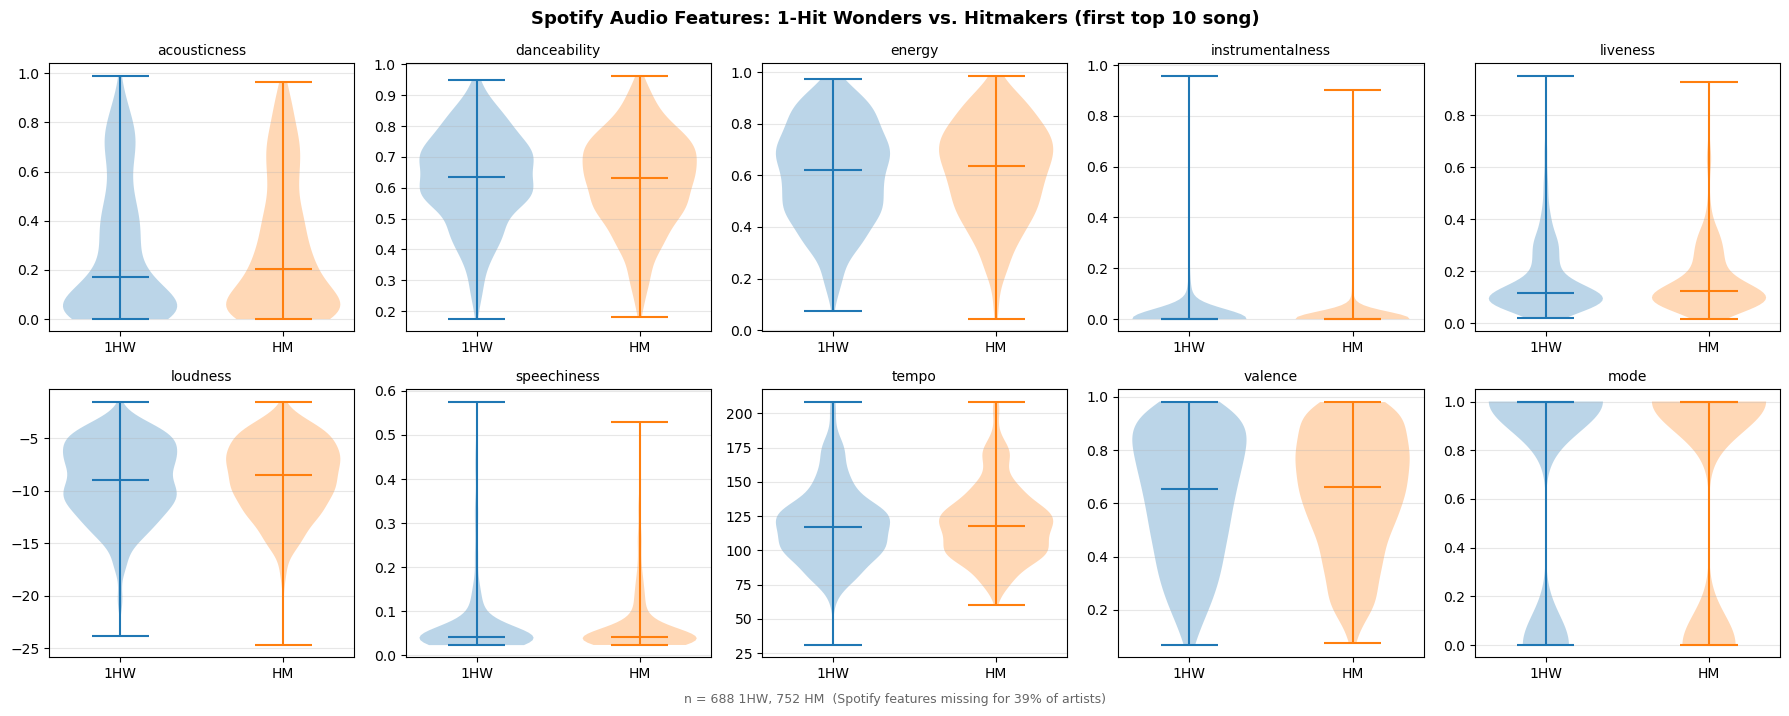

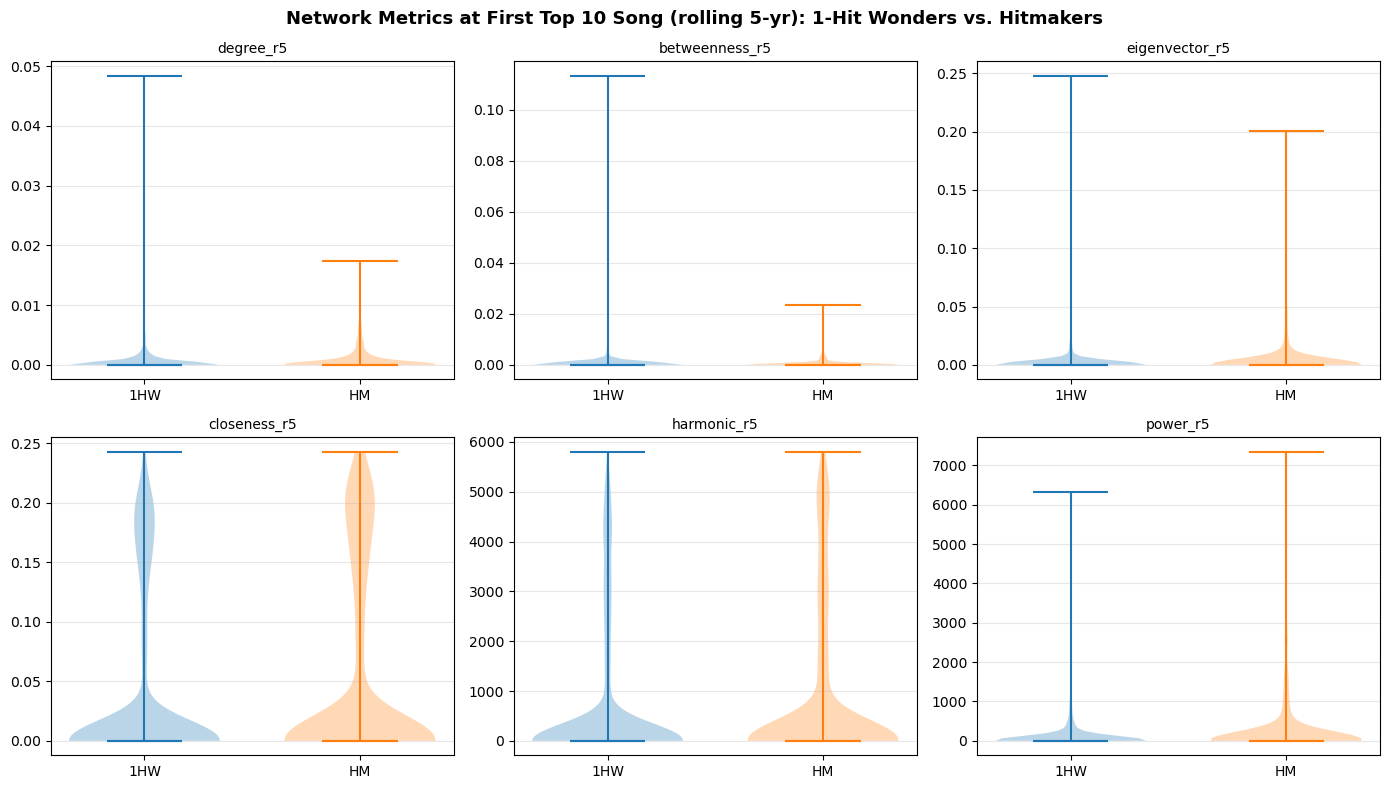

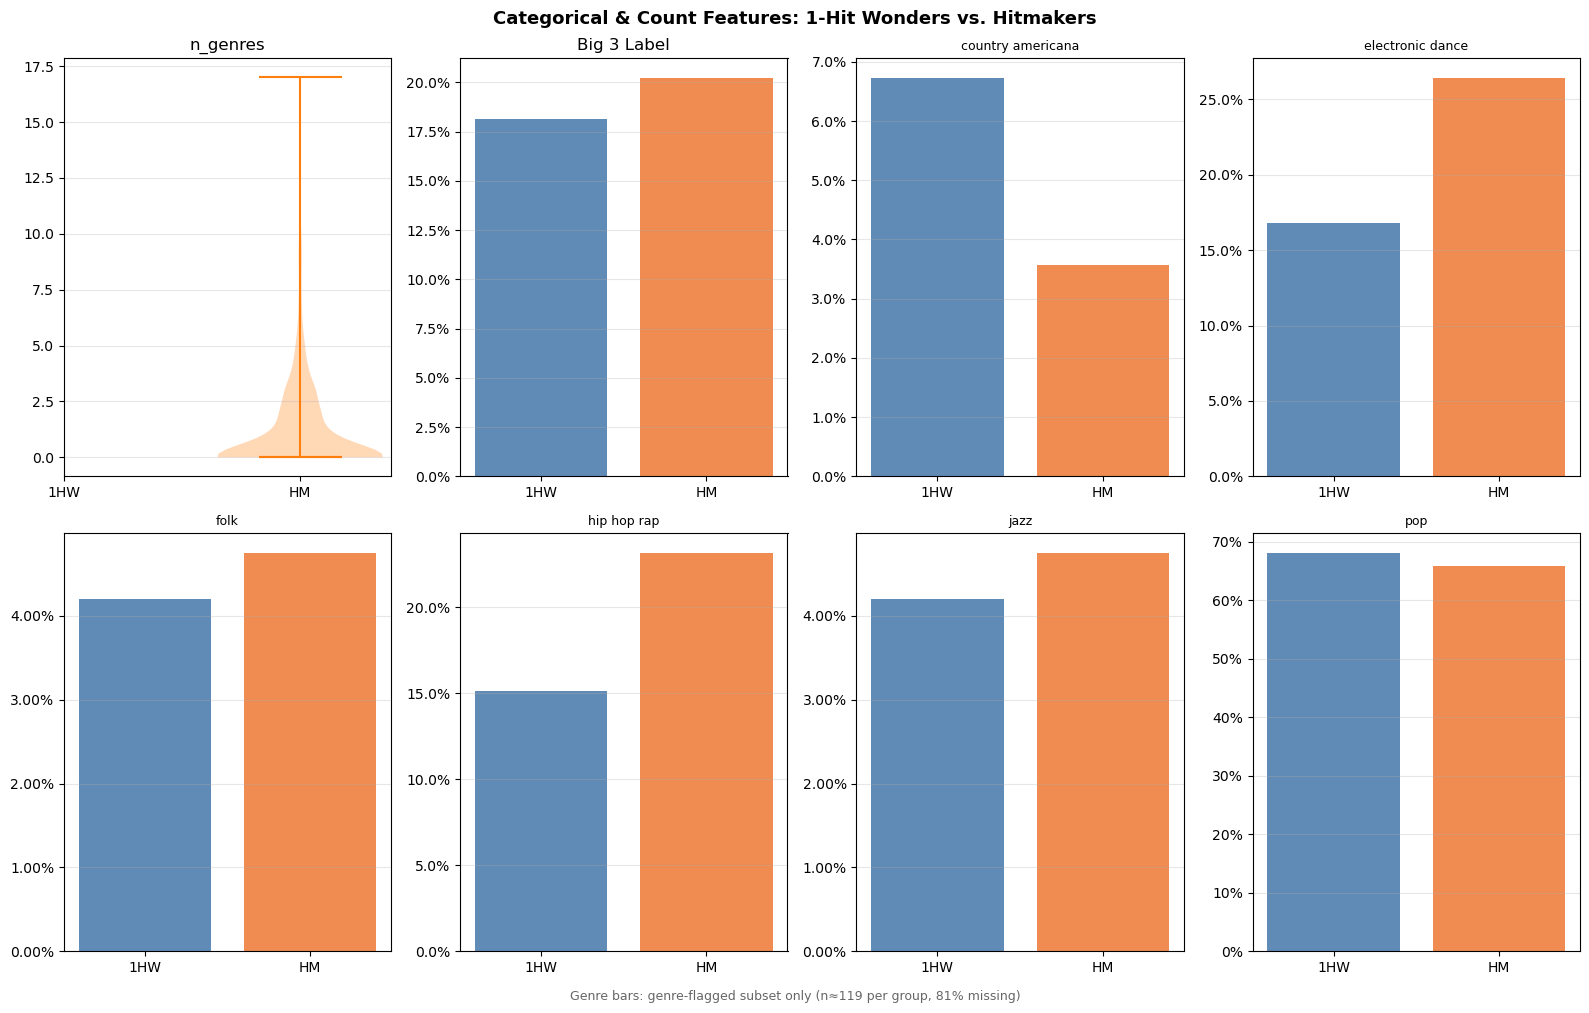

In [8]:
# Visualizations: violin plots for continuous, bar charts for categorical
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

labels = {0: '1-Hit Wonder', 1: 'Hitmaker'}
palette = {0: '#4477AA', 1: '#EE7733'}

# ── Fig 1: Spotify audio features ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle('Spotify Audio Features: 1-Hit Wonders vs. Hitmakers (first top 10 song)',
             fontsize=13, fontweight='bold')

sub_sp = df_ml[df_ml['acousticness'].notna()]
for ax, col in zip(axes.flat, audio_cols):
    for val, color in palette.items():
        data = sub_sp[sub_sp['hitmaker'] == val][col].dropna()
        ax.violinplot(data, positions=[val], showmedians=True, widths=0.7)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['1HW', 'HM'])
    ax.set_title(col, fontsize=10)
    ax.grid(axis='y', alpha=0.3)

# note missing data
fig.text(0.5, -0.01, f'n = {sub_sp["hitmaker"].value_counts()[0]} 1HW, '
         f'{sub_sp["hitmaker"].value_counts()[1]} HM  '
         f'(Spotify features missing for {df_ml["acousticness"].isna().mean()*100:.0f}% of artists)',
         ha='center', fontsize=9, color='#666')
plt.tight_layout()
plt.show()

# ── Fig 2: Network metrics ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Network Metrics at First Top 10 Song (rolling 5-yr): 1-Hit Wonders vs. Hitmakers',
             fontsize=13, fontweight='bold')

for ax, col in zip(axes.flat, nm_cols):
    for val, color in palette.items():
        data = df_ml[df_ml['hitmaker'] == val][col]
        ax.violinplot(data, positions=[val], showmedians=True, widths=0.7)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['1HW', 'HM'])
    ax.set_title(col, fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ── Fig 3: n_genres + big3_label + genre categories ────────────────────────────
fig = plt.figure(figsize=(16, 10))
fig.suptitle('Categorical & Count Features: 1-Hit Wonders vs. Hitmakers',
             fontsize=13, fontweight='bold')

# n_genres violin
ax1 = fig.add_subplot(2, 4, 1)
for val in [0, 1]:
    ax1.violinplot(df_ml[df_ml['hitmaker']==val]['n_genres'], positions=[val],
                   showmedians=True, widths=0.7)
ax1.set_xticks([0,1]); ax1.set_xticklabels(['1HW','HM'])
ax1.set_title('n_genres'); ax1.grid(axis='y', alpha=0.3)

# big3 label bar
ax2 = fig.add_subplot(2, 4, 2)
for i, val in enumerate([0, 1]):
    pct = 100 * df_ml[df_ml['hitmaker']==val]['big3_label'].mean()
    ax2.bar(i, pct, color=list(palette.values())[i], alpha=0.85)
ax2.set_xticks([0,1]); ax2.set_xticklabels(['1HW','HM'])
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2.set_title('Big 3 Label'); ax2.grid(axis='y', alpha=0.3)

# Genre category bars (only genres with enough data)
genre_sub = df_ml[df_ml['genre_str'].notna()]
valid_genres = [c for c in genre_cols if genre_sub[c].sum() >= 20]
axes_genre = [fig.add_subplot(2, 4, i+3) for i in range(min(6, len(valid_genres)))]

for ax, col in zip(axes_genre, valid_genres[:6]):
    sub = df_ml[df_ml[col].notna()]
    for i, val in enumerate([0, 1]):
        pct = 100 * sub[sub['hitmaker']==val][col].mean()
        ax.bar(i, pct, color=list(palette.values())[i], alpha=0.85)
    ax.set_xticks([0,1]); ax.set_xticklabels(['1HW','HM'])
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_title(col.replace('genre_','').replace('_',' '), fontsize=9)
    ax.grid(axis='y', alpha=0.3)

fig.text(0.5, -0.01, f'Genre bars: genre-flagged subset only '
         f'(n≈{genre_sub["hitmaker"].value_counts().min()} per group, '
         f'{df_ml["genre_str"].isna().mean()*100:.0f}% missing)',
         ha='center', fontsize=9, color='#666')
plt.tight_layout()
plt.show()


MusicBrainz major genre categories
  1-hit wonder  n=920  median=2.0  mean=2.18
  hitmaker      n=801  median=2.0  mean=2.48
  Mann-Whitney p=0.0000  r=0.157  ***

Spotify major genre categories
  1-hit wonder  n=397  median=2.0  mean=1.70
  hitmaker      n=577  median=2.0  mean=2.02
  Mann-Whitney p=0.0000  r=0.177  ***



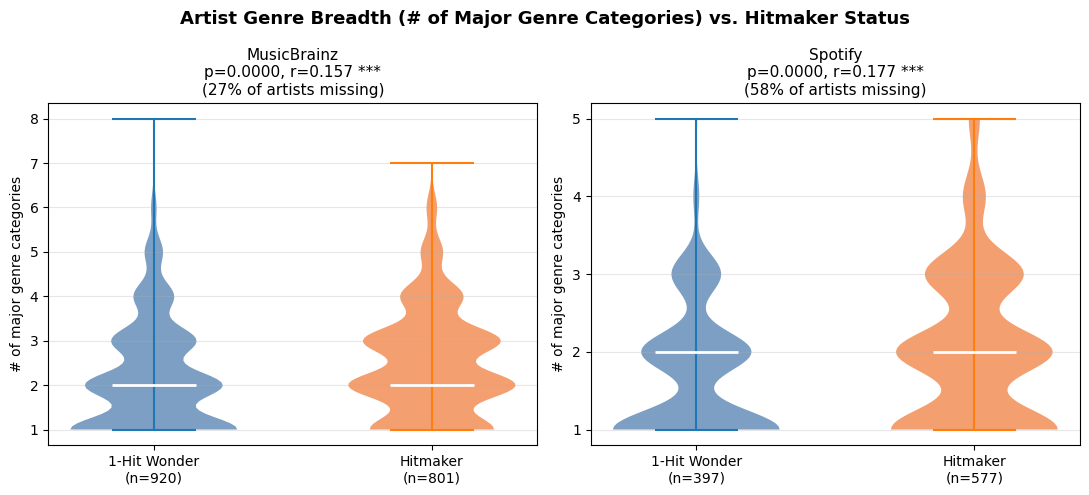

In [9]:
# Relationship between artist-level genre breadth and hitmaker status
# Using df_artists: # of MusicBrainz major genre categories and # of Spotify major genre categories

# --- Derive counts from the major genre category strings ---
genre_breadth = df_artists[['name', 'top_10_song_count',
                             'musicbrainz_major_genre_categories',
                             'spotify_major_genre_categories']].copy()

genre_breadth = genre_breadth[genre_breadth['top_10_song_count'] >= 1].copy()
genre_breadth['hitmaker'] = (genre_breadth['top_10_song_count'] >= 2).astype(int)

def count_categories(s):
    if pd.isna(s) or str(s).strip() == '':
        return np.nan
    return len([x for x in s.split(',') if x.strip()])

genre_breadth['n_mb_major_genres']      = genre_breadth['musicbrainz_major_genre_categories'].apply(count_categories)
genre_breadth['n_spotify_major_genres'] = genre_breadth['spotify_major_genre_categories'].apply(count_categories)

# --- Stats ---
for col, label in [('n_mb_major_genres',      'MusicBrainz major genre categories'),
                   ('n_spotify_major_genres',  'Spotify major genre categories')]:
    wonders = genre_breadth[genre_breadth['hitmaker'] == 0][col].dropna()
    makers  = genre_breadth[genre_breadth['hitmaker'] == 1][col].dropna()
    _, p = stats.mannwhitneyu(wonders, makers, alternative='two-sided')
    r    = rank_biserial(wonders.values, makers.values)
    sig  = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    print(f'{label}')
    print(f'  1-hit wonder  n={len(wonders):,}  median={wonders.median():.1f}  mean={wonders.mean():.2f}')
    print(f'  hitmaker      n={len(makers):,}  median={makers.median():.1f}  mean={makers.mean():.2f}')
    print(f'  Mann-Whitney p={p:.4f}  r={r:.3f}  {sig}')
    print()

# --- Visual ---
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
fig.suptitle("Artist Genre Breadth (# of Major Genre Categories) vs. Hitmaker Status",
             fontsize=13, fontweight='bold')

for ax, col, label, null_pct in [
    (axes[0], 'n_mb_major_genres',     'MusicBrainz',
     genre_breadth['n_mb_major_genres'].isna().mean()),
    (axes[1], 'n_spotify_major_genres', 'Spotify',
     genre_breadth['n_spotify_major_genres'].isna().mean()),
]:
    for val, color, lbl in [(0, '#4477AA', '1-Hit Wonder'), (1, '#EE7733', 'Hitmaker')]:
        data = genre_breadth[genre_breadth['hitmaker'] == val][col].dropna()
        parts = ax.violinplot(data, positions=[val], showmedians=True, widths=0.6)
        for pc in parts['bodies']:
            pc.set_facecolor(color)
            pc.set_alpha(0.7)
        parts['cmedians'].set_color('white')
        parts['cmedians'].set_linewidth(2)

    wonders = genre_breadth[genre_breadth['hitmaker'] == 0][col].dropna()
    makers  = genre_breadth[genre_breadth['hitmaker'] == 1][col].dropna()
    _, p = stats.mannwhitneyu(wonders, makers, alternative='two-sided')
    r    = rank_biserial(wonders.values, makers.values)
    sig  = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))

    ax.set_xticks([0, 1])
    ax.set_xticklabels([f'1-Hit Wonder\n(n={len(wonders):,})', f'Hitmaker\n(n={len(makers):,})'])
    ax.set_ylabel('# of major genre categories')
    ax.set_title(f'{label}\np={p:.4f}, r={r:.3f} {sig}\n({null_pct*100:.0f}% of artists missing)',
                 fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()


2001–2020 artists with ≥1 top 10 song: 532
  1-hit wonders: 315
  Hitmakers:     217
  MB genre null:      21.8%
  Spotify genre null: 33.8%

MusicBrainz major genre categories
  1-hit wonder  n=228  median=2.0  mean=2.14
  hitmaker      n=188  median=2.0  mean=2.36
  Mann-Whitney p=0.0585  r=0.104  ns

Spotify major genre categories
  1-hit wonder  n=164  median=1.0  mean=1.58
  hitmaker      n=188  median=1.0  mean=1.68
  Mann-Whitney p=0.2227  r=0.068  ns



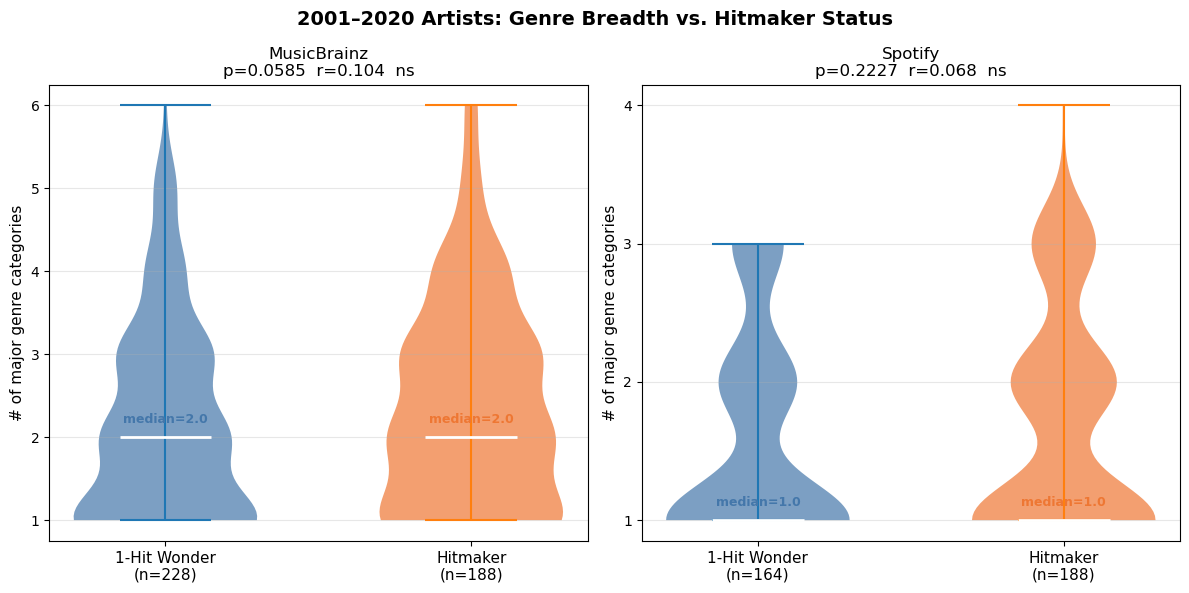

In [11]:
# Genre breadth vs. hitmaker status — artists whose first top 10 song was 2001–2020

genre_breadth_01_20 = (genre_breadth
                        .merge(df_ml[['name', 'first_top10_year']], on='name', how='left')
                        .query('2001 <= first_top10_year <= 2020'))

print(f"2001–2020 artists with ≥1 top 10 song: {len(genre_breadth_01_20)}")
print(f"  1-hit wonders: {(genre_breadth_01_20['hitmaker']==0).sum()}")
print(f"  Hitmakers:     {(genre_breadth_01_20['hitmaker']==1).sum()}")
print(f"  MB genre null:      {genre_breadth_01_20['n_mb_major_genres'].isna().mean():.1%}")
print(f"  Spotify genre null: {genre_breadth_01_20['n_spotify_major_genres'].isna().mean():.1%}")
print()

for col, label in [('n_mb_major_genres',     'MusicBrainz major genre categories'),
                   ('n_spotify_major_genres', 'Spotify major genre categories')]:
    wonders = genre_breadth_01_20[genre_breadth_01_20['hitmaker'] == 0][col].dropna()
    makers  = genre_breadth_01_20[genre_breadth_01_20['hitmaker'] == 1][col].dropna()
    _, p = stats.mannwhitneyu(wonders, makers, alternative='two-sided')
    r    = rank_biserial(wonders.values, makers.values)
    sig  = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    print(f'{label}')
    print(f'  1-hit wonder  n={len(wonders):,}  median={wonders.median():.1f}  mean={wonders.mean():.2f}')
    print(f'  hitmaker      n={len(makers):,}  median={makers.median():.1f}  mean={makers.mean():.2f}')
    print(f'  Mann-Whitney p={p:.4f}  r={r:.3f}  {sig}')
    print()

# --- Visual ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle("2001–2020 Artists: Genre Breadth vs. Hitmaker Status",
             fontsize=14, fontweight='bold')

for ax, col, label in [
    (axes[0], 'n_mb_major_genres',     'MusicBrainz'),
    (axes[1], 'n_spotify_major_genres', 'Spotify'),
]:
    sub     = genre_breadth_01_20[['hitmaker', col]].dropna()
    wonders = sub[sub['hitmaker'] == 0][col]
    makers  = sub[sub['hitmaker'] == 1][col]

    _, p = stats.mannwhitneyu(wonders, makers, alternative='two-sided')
    r    = rank_biserial(wonders.values, makers.values)
    sig  = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))

    for val, color in [(0, '#4477AA'), (1, '#EE7733')]:
        data  = sub[sub['hitmaker'] == val][col]
        parts = ax.violinplot(data, positions=[val], showmedians=True, widths=0.6)
        for pc in parts['bodies']:
            pc.set_facecolor(color)
            pc.set_alpha(0.7)
        parts['cmedians'].set_color('white')
        parts['cmedians'].set_linewidth(2)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(
        [f'1-Hit Wonder\n(n={len(wonders):,})', f'Hitmaker\n(n={len(makers):,})'],
        fontsize=11)
    ax.set_ylabel('# of major genre categories', fontsize=11)
    ax.set_title(f'{label}\np={p:.4f}  r={r:.3f}  {sig}', fontsize=12)
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.grid(axis='y', alpha=0.3)

    for val, color in [(0, '#4477AA'), (1, '#EE7733')]:
        med = sub[sub['hitmaker'] == val][col].median()
        ax.annotate(f'median={med:.1f}', xy=(val, med), xytext=(0, 10),
                    textcoords='offset points', ha='center',
                    fontsize=9, color=color, fontweight='bold')

plt.tight_layout()
plt.show()


In [12]:
# Full statistical analysis — same as before, filtered to 2001–2020 debut artists

df_ml_01_20 = df_ml.query('2001 <= first_top10_year <= 2020').copy()

print(f"2001–2020 artists: {len(df_ml_01_20)}  "
      f"(1HW: {(df_ml_01_20['hitmaker']==0).sum()}, "
      f"HM: {(df_ml_01_20['hitmaker']==1).sum()})")
print()

wonders = df_ml_01_20[df_ml_01_20['hitmaker'] == 0]
makers  = df_ml_01_20[df_ml_01_20['hitmaker'] == 1]

rows = []

for col in audio_cols + nm_cols + ['n_genres']:
    a = wonders[col].dropna().values
    b = makers[col].dropna().values
    if len(a) < 10 or len(b) < 10:
        continue
    _, p = stats.mannwhitneyu(a, b, alternative='two-sided')
    r    = rank_biserial(a, b)
    rows.append(dict(feature=col, test='mann-whitney',
                     val_1hw=f'{np.median(a):.3f}', val_hm=f'{np.median(b):.3f}',
                     n_1hw=len(a), n_hm=len(b), p=p, effect=r, effect_label='r'))

for col in ['big3_label'] + genre_cols:
    sub = df_ml_01_20[df_ml_01_20[col].notna()].copy()
    ct  = pd.crosstab(sub[col], sub['hitmaker'])
    if ct.shape[0] < 2 or ct.shape[1] < 2:
        continue
    n_1hw = ct[0].sum() if 0 in ct.columns else 0
    n_hm  = ct[1].sum() if 1 in ct.columns else 0
    pct_1hw = 100 * ct.loc[1, 0] / n_1hw if (1 in ct.index and n_1hw > 0) else np.nan
    pct_hm  = 100 * ct.loc[1, 1] / n_hm  if (1 in ct.index and n_hm  > 0) else np.nan
    if ct.values.min() < 5:
        oddsratio, p = stats.fisher_exact(ct.values)
        test = 'fisher'
    else:
        chi2, p, _, _ = stats.chi2_contingency(ct.values)
        oddsratio = ((ct.loc[1,1] * ct.loc[0,0]) / (ct.loc[1,0] * ct.loc[0,1])
                     if ct.loc[1,0] * ct.loc[0,1] > 0 else np.nan)
        test = 'chi2'
    rows.append(dict(feature=col, test=test,
                     val_1hw=f'{pct_1hw:.1f}%', val_hm=f'{pct_hm:.1f}%',
                     n_1hw=int(n_1hw), n_hm=int(n_hm), p=p,
                     effect=oddsratio, effect_label='OR'))

# Add genre breadth columns from genre_breadth_01_20
for col, label in [('n_mb_major_genres', 'n_mb_major_genres'),
                   ('n_spotify_major_genres', 'n_spotify_major_genres')]:
    sub = genre_breadth_01_20[['hitmaker', col]].dropna()
    a   = sub[sub['hitmaker'] == 0][col].values
    b   = sub[sub['hitmaker'] == 1][col].values
    if len(a) < 10 or len(b) < 10:
        continue
    _, p = stats.mannwhitneyu(a, b, alternative='two-sided')
    r    = rank_biserial(a, b)
    rows.append(dict(feature=col, test='mann-whitney',
                     val_1hw=f'{np.median(a):.3f}', val_hm=f'{np.median(b):.3f}',
                     n_1hw=len(a), n_hm=len(b), p=p, effect=r, effect_label='r'))

res_01_20 = (pd.DataFrame(rows)
             .sort_values('p')
             .assign(sig=lambda d: d['p'].apply(
                 lambda p: '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else '')))))

res_01_20['p']      = res_01_20['p'].map('{:.4f}'.format)
res_01_20['effect'] = res_01_20['effect'].map('{:.3f}'.format)

print(res_01_20[['feature','test','val_1hw','val_hm','n_1hw','n_hm','p','effect','effect_label','sig']]
      .to_string(index=False))


2001–2020 artists: 532  (1HW: 315, HM: 217)

                       feature         test  val_1hw   val_hm  n_1hw  n_hm      p effect effect_label sig
                betweenness_r5 mann-whitney    0.000    0.000    315   217 0.0000  0.369            r ***
                     degree_r5 mann-whitney    0.000    0.001    315   217 0.0000  0.373            r ***
                  closeness_r5 mann-whitney    0.161    0.193    315   217 0.0000  0.354            r ***
                eigenvector_r5 mann-whitney    0.000    0.005    315   217 0.0000  0.352            r ***
                      power_r5 mann-whitney   99.000  481.500    315   217 0.0000  0.346            r ***
                   harmonic_r5 mann-whitney 2437.932 3282.808    315   217 0.0000  0.294            r ***
                          mode mann-whitney    1.000    1.000    170   170 0.0105 -0.135            r   *
                    genre_rock         chi2    36.1%    16.1%     36   124 0.0176  0.340           OR   *
 